In [1]:
# %pylab inline 
import numpy as np #                        #::::: not with pylab inline
import scipy   
from scipy import special   

#from mpmath import hyperu
#from scipy import linalg                   # ::::: not with pylab inline ??     
#from scipy import special  
#from scipy import stats   
from scipy.interpolate import InterpolatedUnivariateSpline 
import matplotlib.pyplot as plt   
import cmath   
from modules_rel import* 
from modules_for_Bcomplex import* 
from modules_hyper import*
#from delaymodules import* 

import importlib

#importlib.reload(modules_rel)
#importlib.reload(modules_for_Bcomplex)
    
   
# close('all')     
 
 
# needed natural constants
ij=complex(0.0,1.0)
eV = 27.211384 
atto = 24.18884326505
cpeed=137.035999074 
cm2=0.52917721092**2*100.0 
cross_const=(4.0/3.0)/cpeed*np.pi*cm2
# Nuclear charge 
Zcharge=1.0
#folderprint='/home/lindroth/programming/for/Bspline/forXin/src/figures_restart/'

In [2]:
#   Practical definitions for plotting
#
myline1='-'   #  | '-' | '--' | '-.' | ':' | 
myline2='--'   #  | '-' | '--' | '-.' | ':' | 
myline3='-.'   #  | '-' | '--' | '-.' | ':' |  
mycolor1='Blue'
mycolor2='Red'   
mycolor3='0.55'  # shades of gray - darker with smaller number 
mycolor4='Green' 
mycolor5='Brown'  
mycolor6='Purple' 
mycolor7='Magenta' 
mycolor8='Orange'     
    
myfontsize = 14 # change for presentation plots
mylegendsize=14 # change for presentation plots
mylegendsizelarge=20 # change for presentation plots    
myticksize=14 # change for presentation plots   
myfontsizelarge=18 # change for presentation plots 
myfontsizesmall=12 # change for presentation plots 
#   Fixing the fonts
font = {'family': 'sans-serif','weight': 'normal','size': myfontsize, }    
fontlarge = {'family': 'sans-serif','weight': 'normal','size': myfontsizelarge, }  
fontsmall = {'family': 'sans-serif','weight': 'normal','size': myfontsizesmall, }  
ppsize1=8
ppsize2=4

In [3]:
# t-seq. construction - make your own
def lineargrid(kord,Rot,rmax,fi,h,plus1,mult,doexp,nn):
    dt = np.complex128
    theta=fi/180.0*np.pi
   
    if(np.logical_and(Rot<rmax,doexp==0)):
        nknot=2*(kord-1) +int((Rot+0.0000000001)/h) +int((rmax-Rot+0.0000000001)/nn/h) +1 +3 +plus1 +mult
        print(' linear grid: step size before rotation',h,' linear grid: stepsize after rotation',h*nn)
    elif(np.logical_and(Rot<rmax,doexp==1)):
        hexp=np.log((Rot+nn*h)/Rot)
        nexp=int(np.log((rmax+0.000000000001)/Rot)/hexp)
        print (' linear grid: step size before rotation',h,' after rotation',nexp,\
               ' expontial points wirh e^',hexp)
        nknot=2*(kord-1) +int((Rot+0.0000000001)/h) +nexp +1 +3 +plus1 +mult
    else:
        nknot=2*(kord-1) +int((rmax+0.0000000001)/h) +1 +3 +plus1 +mult
    
    print('number of knotpoints=',nknot,' rotation from',Rot,' theta=',theta,' radians')
    t=np.zeros(nknot,dtype=dt)
    i=0
    while i< kord:
        t[i]=complex(0.0,0.0)
        t[nknot-i-1-mult]=complex((1.0 +plus1)*rmax,0.0)
        i=i+1
    i=kord
    hsmall=h/4.0
    while i< kord+4:
        t[i]=t[i-1] +hsmall
        i=i+1
    i=kord+4  
    while i<nknot- kord -mult:
        if np.logical_and(Rot<rmax,np.real(t[i-1-mult])<Rot):
            t[i]=t[i-1] +h
#            print(' inner',i,t[i])
        elif(Rot<rmax):
            if(doexp):
                t[i]=t[i-1]*np.exp(hexp)
            else:
                t[i]=t[i-1] +nn*h
#            print(' outer',i,t[i])
        i=i+1
    i=0
    ij=complex(0.0,1.0)
    iclose=10**10
    while i<nknot:
        if(np.real(t[i])>Rot):
            t[i]=Rot+(t[i]-Rot)*np.exp(ij*theta)
#            print(' rotated',i,t[i])
            if(i<iclose):
                iclose=i
#        print(i,t[i])
        i=i+1 
    print('rotation from knot nr',iclose-1, '(1st knot= # 0)where there are ',mult,' extra points')
    
    i=nknot-1
    while i>iclose-1:
        t[i]=t[i-mult]
        i=i-1
    i=iclose
    while i< iclose +mult:
        t[i]=t[iclose-1]
        i=i+1
    print('t in',iclose-1,t[iclose-1],'t in',iclose-1+mult,t[iclose-1+mult])
    return nknot,t,iclose-1

In [4]:
#CALLING for LINEAR GRID
#Non-rel knot sequence
linear=1
if(linear):
    filin=15.0 
    
    rotlin=80.0
#    rotlin=73.27
#     rotlin=71.81
#     rmaxlin=100.0
    rmaxlin=rotlin+40.0 
#     rmaxlin=112.87
#     rmaxlin=110.61
    kord=7
#     hlin=0.97 
    hlin=1.0
#    hlin=0.5
#    hlin=2.0
    
    plus1=0
    multlin=0
    doexp=0
    nn=1.0
    nknot,t,iclose=lineargrid(kord,rotlin,rmaxlin,filin,hlin,plus1,multlin,doexp,nn)
    textmax=str(int((plus1+1)*rmaxlin))
    print('last point',t[nknot-1],' deltar =',np.real(t[nknot-1])-rotlin)
#    print('rotation from ',t[iclose])
    i=0
    while i<nknot:
        print(i,t[i])
        i=i+1

 linear grid: step size before rotation 1.0  linear grid: stepsize after rotation 1.0
number of knotpoints= 136  rotation from 80.0  theta= 0.2617993877991494  radians
rotation from knot nr 89 (1st knot= # 0)where there are  0  extra points
t in 89 (80+0j) t in 89 (80+0j)
last point (118.63703305156272+10.35276180410083j)  deltar = 38.637033051562724
0 0j
1 0j
2 0j
3 0j
4 0j
5 0j
6 0j
7 (0.25+0j)
8 (0.5+0j)
9 (0.75+0j)
10 (1+0j)
11 (2+0j)
12 (3+0j)
13 (4+0j)
14 (5+0j)
15 (6+0j)
16 (7+0j)
17 (8+0j)
18 (9+0j)
19 (10+0j)
20 (11+0j)
21 (12+0j)
22 (13+0j)
23 (14+0j)
24 (15+0j)
25 (16+0j)
26 (17+0j)
27 (18+0j)
28 (19+0j)
29 (20+0j)
30 (21+0j)
31 (22+0j)
32 (23+0j)
33 (24+0j)
34 (25+0j)
35 (26+0j)
36 (27+0j)
37 (28+0j)
38 (29+0j)
39 (30+0j)
40 (31+0j)
41 (32+0j)
42 (33+0j)
43 (34+0j)
44 (35+0j)
45 (36+0j)
46 (37+0j)
47 (38+0j)
48 (39+0j)
49 (40+0j)
50 (41+0j)
51 (42+0j)
52 (43+0j)
53 (44+0j)
54 (45+0j)
55 (46+0j)
56 (47+0j)
57 (48+0j)
58 (49+0j)
59 (50+0j)
60 (51+0j)
61 (52+0j)
62 (53+0j)
63 

In [5]:
#Construct Gaussian Grid
rr,weights,ig=getgaussiangrid(t,nknot,kord,multlin)

this is the gaussian grid, with 8  points between each  knot point


In [6]:
# This is a relativitisc knot sequence: nknotf points and k=kf for the large component (lying in tf)
#                                       nknotg points and k=kg for the small component (lying in tg)
kordf=kord
kordg=kordf+1
print(' knotsequence: kordf=',kordf,'kordg=',kordg)
dt = np.complex128
if(kordg > kordf):
    # Here we use kordg=kordf+1
    nknotf=nknot
    nknotg=nknotf+(kordg-kordf)*2
    print(' knotsequence: nknotf=',nknotf,'nknotg=',nknotg)
#    print(nknotf,kordf,nknotg,kordg)
    tf=np.zeros(nknotf,dtype=dt)
    tg=np.zeros(nknotg,dtype=dt)
    i=kordf-1
    while i<t.size:  
        tf[i]=t[i]
        tg[i+kordg-kordf]=t[i]
        i=i+1
    i=1
    while i<kordg-kordf+1:
        tg[tg.size-i]=tg[tg.size-kordg+1]
        i=i+1
elif(kordg < kordf):
        # Here we use kordf=kordg+1
    nknotf=nknot+2
    nknotg=nknot
    print(nknotf,kordf,nknotg,kordg)
    tf=np.zeros(nknotf,dtype=dt)
    tg=np.zeros(nknotg,dtype=dt)
    i=kordg-1
    while i<t.size:  
        tg[i]=t[i]
        tf[i+1]=t[i]
        i=i+1   
    tf[tf.size-1]=tf[tf.size-2]
else:
    nknotf=nknot
    nknotg=nknot
    print(nknotf,kordf,nknotg,kordg)
    tf=np.zeros(nknotf,dtype=dt)
    tg=np.zeros(nknotg,dtype=dt)
    i=kordf-1
    while i<t.size:  
        tf[i]=t[i]
        tg[i]=t[i]   
        i = i+1

 knotsequence: kordf= 7 kordg= 8
 knotsequence: nknotf= 136 nknotg= 138


In [7]:
doprint=1
if(doprint):
    i=0
    while i<nknotg:
        if i<kordg-kordf:
            print(i,tg[i])
        elif i<nknotf +kordg-kordf :
            print(i,tg[i],tf[i-(kordg-kordf)])
        else:
            print(i,tg[i])
        i=i+1

0 0j
1 0j 0j
2 0j 0j
3 0j 0j
4 0j 0j
5 0j 0j
6 0j 0j
7 0j 0j
8 (0.25+0j) (0.25+0j)
9 (0.5+0j) (0.5+0j)
10 (0.75+0j) (0.75+0j)
11 (1+0j) (1+0j)
12 (2+0j) (2+0j)
13 (3+0j) (3+0j)
14 (4+0j) (4+0j)
15 (5+0j) (5+0j)
16 (6+0j) (6+0j)
17 (7+0j) (7+0j)
18 (8+0j) (8+0j)
19 (9+0j) (9+0j)
20 (10+0j) (10+0j)
21 (11+0j) (11+0j)
22 (12+0j) (12+0j)
23 (13+0j) (13+0j)
24 (14+0j) (14+0j)
25 (15+0j) (15+0j)
26 (16+0j) (16+0j)
27 (17+0j) (17+0j)
28 (18+0j) (18+0j)
29 (19+0j) (19+0j)
30 (20+0j) (20+0j)
31 (21+0j) (21+0j)
32 (22+0j) (22+0j)
33 (23+0j) (23+0j)
34 (24+0j) (24+0j)
35 (25+0j) (25+0j)
36 (26+0j) (26+0j)
37 (27+0j) (27+0j)
38 (28+0j) (28+0j)
39 (29+0j) (29+0j)
40 (30+0j) (30+0j)
41 (31+0j) (31+0j)
42 (32+0j) (32+0j)
43 (33+0j) (33+0j)
44 (34+0j) (34+0j)
45 (35+0j) (35+0j)
46 (36+0j) (36+0j)
47 (37+0j) (37+0j)
48 (38+0j) (38+0j)
49 (39+0j) (39+0j)
50 (40+0j) (40+0j)
51 (41+0j) (41+0j)
52 (42+0j) (42+0j)
53 (43+0j) (43+0j)
54 (44+0j) (44+0j)
55 (45+0j) (45+0j)
56 (46+0j) (46+0j)
57 (47+0j) (47+0j)

In [8]:
# generate s, p1/2 and p3/2
ilastf=0
ilastg=0
ll=0
jj=1/2
eigs1,vecs1,brel,dip_rel=setuph_rel(rr,weights,tf,tg,nknotf,nknotg,kordf,kordg,\
                                    Zcharge,ll,jj,ig,cpeed,ilastf,ilastg)  
ll=1
jj=1/2
eigp1,vecp1,brel,dip_rel=setuph_rel(rr,weights,tf,tg,nknotf,nknotg,kordf,kordg,\
                                    Zcharge,ll,jj,ig,cpeed,ilastf,ilastg) 
ll=1
jj=3/2
eigp3,vecp3,brel,dip_rel=setuph_rel(rr,weights,tf,tg,nknotf,nknotg,kordf,kordg,\
                                    Zcharge,ll,jj,ig,cpeed,ilastf,ilastg)

 Relativistic case: constructing matricies with dimension 127  ig= 8  ilast= 0
 Relativistic case: constructing matricies with dimension 128  ig= 8  ilast= 0
 Relativistic case: constructing non-diagonal matricies with dimension 127  x  128  ilastf= 0  ilastg= 0
the Dirac matrix for kappa= -1  has dimension 255
 result for zggev 0
 Relativistic case: constructing matricies with dimension 127  ig= 8  ilast= 0
 Relativistic case: constructing matricies with dimension 128  ig= 8  ilast= 0
 Relativistic case: constructing non-diagonal matricies with dimension 127  x  128  ilastf= 0  ilastg= 0
the Dirac matrix for kappa= 1  has dimension 255
 result for zggev 0
 Relativistic case: constructing matricies with dimension 127  ig= 8  ilast= 0
 Relativistic case: constructing matricies with dimension 128  ig= 8  ilast= 0
 Relativistic case: constructing non-diagonal matricies with dimension 127  x  128  ilastf= 0  ilastg= 0
the Dirac matrix for kappa= -2  has dimension 255
 result for zggev 0


In [9]:
istart=nknotg-kordg-2+ilastg
i=istart
nmbr=5
eigas1=np.argsort(eigs1)
print('first few eigenvalues for s1/2')

#print(eigs1[eigas1[::-1]])

while i<nknotf-kordf-2+nmbr:
    print(i,eigs1[eigas1[i]])
    i=i+1
eigap1=np.argsort(eigp1)
i=istart
print('first few eigenvalues for p1/2' )
while i<nknotf-kordf-2+nmbr:
    print(i,eigp1[eigap1[i]])
    i=i+1
eigap3=np.argsort(eigp3)
i=istart
print('first few  eigenvalues for p3/2' )
while i<nknotf-kordf-2+nmbr:
    print(i,eigp3[eigap3[i]])
    i=i+1

first few eigenvalues for s1/2
128 (-0.5000066563721353+1.1152578394058438e-13j)
129 (-0.12500208018855674+3.93065842883856e-13j)
130 (-0.05555629517679933-1.3813712865813092e-13j)
131 (-0.03125033802854753+6.163585090611545e-14j)
first few eigenvalues for p1/2
128 (-0.1250020801892722-4.07810461478921e-14j)
129 (-0.055556295176915176+1.3325136499552251e-13j)
130 (-0.031250338029819615-6.561533796042581e-13j)
131 (-0.02000018114777939+2.8498839025350236e-12j)
first few  eigenvalues for p3/2
128 (-0.12500041602922488-2.249992951403741e-14j)
129 (-0.05555580209107043-1.3002619734821817e-13j)
130 (-0.0312501300077781+2.51413089009172e-13j)
131 (-0.02000007463970753+3.500271763628864e-12j)


(-0.5000066563721353+1.1152578394058438e-13j)
(-0.1250020801892722-4.07810461478921e-14j)
(-0.12500041602922488-2.249992951403741e-14j)


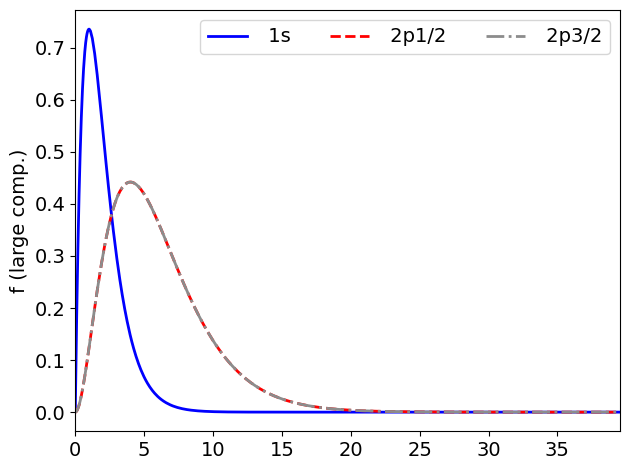

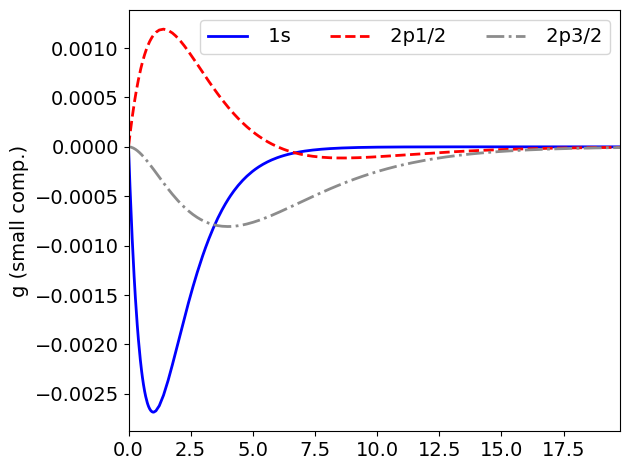

In [10]:
epos_s,vec_pos_s,eneg_s,vec_neg_s=separate_pos_neg(nknotf,kordf,tf,nknotg,kordg,tg,vecs1,eigs1,\
                                                   ilastf,ilastg)
epos_p1,vec_pos_p1,eneg_p1,vec_neg_p1=separate_pos_neg(nknotf,kordf,tf,nknotg,kordg,tg,vecp1,eigp1,\
                                                       ilastf,ilastg)
epos_p3,vec_pos_p3,eneg_p3,vec_neg_p3=separate_pos_neg(nknotf,kordf,tf,nknotg,kordg,tg,vecp3,eigp3,\
                                                       ilastf,ilastg)

print(epos_s[0])
print(epos_p1[0])
print(epos_p3[0])

f1s,g1s= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,vec_pos_s[:,0],rr,ilastf)
f2p1,g2p1= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,vec_pos_p1[:,0],rr,ilastf)
f2p3,g2p3= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,vec_pos_p3[:,0],rr,ilastf)
plt.plot(np.real(rr), np.real(f1s), color=mycolor1,linestyle='-',lw=2,label=' 1s')
plt.plot(np.real(rr), np.real(f2p1), color=mycolor2,linestyle='--',lw=2,label=' 2p1/2')
plt.plot(np.real(rr),np.real(f2p3), color=mycolor3,linestyle='-.',lw=2,label=' 2p3/2')
plt.ylabel('f (large comp.)', fontdict=font) 
plt.xticks(fontsize = myticksize)
plt.yticks(fontsize = myticksize)
plt.xticks(fontsize = myticksize)
printmax=np.real(tf[tf.size-1])/3.0
plt.xlim(0,printmax)
plt.legend(loc='best',prop={'size':mylegendsize},ncol=4)     
plt.tight_layout()
plt.show()
plt.plot(np.real(rr),np.real(g1s), color=mycolor1,linestyle='-',lw=2,label=' 1s')
plt.plot(np.real(rr),np.real(g2p1), color=mycolor2,linestyle='--',lw=2,label=' 2p1/2')
plt.plot(np.real(rr),np.real(g2p3), color=mycolor3,linestyle='-.',lw=2,label=' 2p3/2')
plt.ylabel('g (small comp.)', fontdict=font) 
plt.xticks(fontsize = myticksize)
plt.yticks(fontsize = myticksize)
plt.xticks(fontsize = myticksize)
plt.xlim(0,printmax/2.0)
plt.legend(loc='best',prop={'size':mylegendsize},ncol=4)     
plt.tight_layout()
plt.show()

In [11]:
#XUV_omega, IR_omega
omega=0.6
omega2=1.55/eV
print('omega XUV=',omega*eV,'eV, =',omega,' a.u.')
print('omega IR=',omega2*eV,'eV, =',omega2,' a.u.')

omega XUV= 16.3268304 eV, = 0.6  a.u.
omega IR= 1.55 eV, = 0.0569614540737803  a.u.


In [12]:
#setting up  perturbed wf:s - NOTE just the radial part 
#(we should add the reduced matrix at some point )
wavelength=2.0*np.pi/np.sqrt(np.real(eigs1[eigas1[istart]] +omega) * 2.0)
print('omega=',omega,' a.u.','outgoing electron energi',np.round(np.real(eigs1[eigas1[istart]] +omega),4),\
      'and wavelength =',np.round(wavelength,2),'Bohr radii')
print('starting from E=', eigs1[eigas1[istart]])
# pwf_1s_p1 (from 1s to p_1/2) etc holds the B-spline coeffients 
# including both positive and negative energy states
pwf_1s_p1=perturbedwf(vecs1[:,eigas1[istart]],eigs1[eigas1[istart]],vecp1,eigp1,omega,dip_rel)
pwf_1s_p3=perturbedwf(vecs1[:,eigas1[istart]],eigs1[eigas1[istart]],vecp3,eigp3,omega,dip_rel)
# including jus positive energy states (no real difference)
pwf_1s_p1_pos=perturbedwf(vecs1[:,eigas1[istart]],eigs1[eigas1[istart]],vec_pos_p1,epos_p1,omega,dip_rel)
pwf_1s_p3_pos=perturbedwf(vecs1[:,eigas1[istart]],eigs1[eigas1[istart]],vec_pos_p3,epos_p3,omega,dip_rel)

print(pwf_1s_p1[:5])

omega= 0.6  a.u. outgoing electron energi 0.1 and wavelength = 14.05 Bohr radii
starting from E= (-0.5000066563721353+1.1152578394058438e-13j)
[6.85153574e-05-6.87094764e-06j 7.58098033e-03-2.95880710e-02j
 4.07122474e-02-1.54361960e-01j 1.20061411e-01-4.50008226e-01j
 3.70228738e-01-1.27393153e+00j]


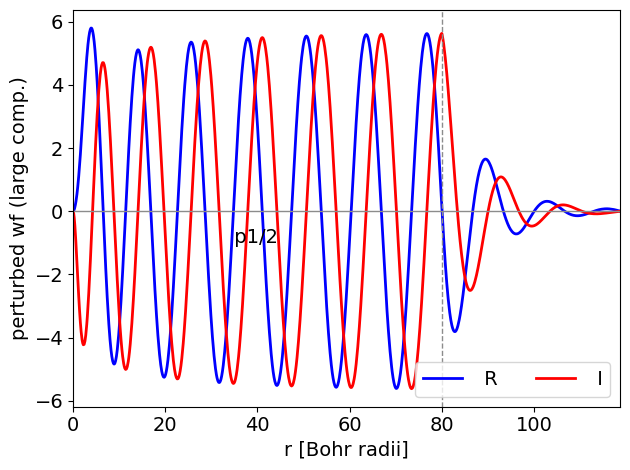

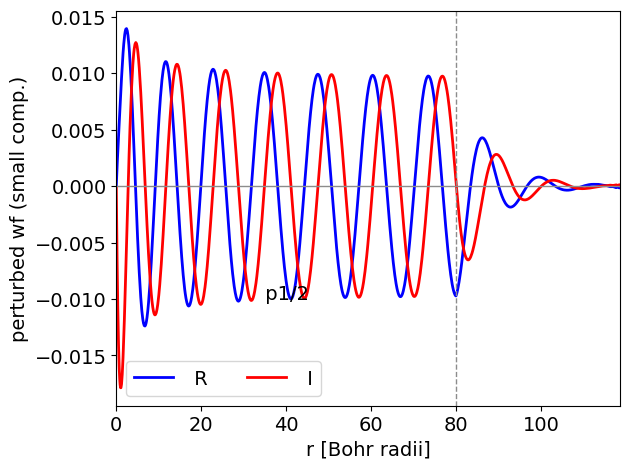

In [13]:
pertf,pertg= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,pwf_1s_p1,rr,ilastf)
pertf_pos,pertg_pos= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,pwf_1s_p1_pos,\
                                      rr,ilastf)
ymin=1.1*np.min(np.imag(pertf))
plt.plot(np.real(rr),np.real(pertf), color=mycolor1,linestyle='-',lw=2,label=' R')
# plt.plot(np.real(rr),np.real (pertf_pos), color=mycolor2,linestyle='--',lw=2,label=' R pos')
plt.plot(np.real(rr),np.imag(pertf), color=mycolor2,linestyle='-',lw=2,label=' I')
plt.axvline(x=rotlin, color=mycolor3, linestyle='--',lw=1)
plt.axhline(y=0.0, color=mycolor3, linestyle='-',lw=1)
plt.xlabel('r [Bohr radii]', fontdict=font)
plt.ylabel('perturbed wf (large comp.)', fontdict=font) 
plt.xticks(fontsize = myticksize)
plt.yticks(fontsize = myticksize)
plt.xlim(0,np.real(t[t.size-1]))
textinfig=' p1/2'
plt.text(printmax*0.85, -1,textinfig, fontdict=font)
plt.legend(loc='best',prop={'size':mylegendsize},ncol=4)     
plt.tight_layout()
plt.show()
#############################
plt.plot(np.real(rr), np.real(pertg), color=mycolor1,linestyle='-',lw=2,label=' R')
# plt.plot(np.real(rr), np.real(pertg_pos), color=mycolor2,linestyle='--',lw=2,label=' R pos')
plt.plot(np.real(rr), np.imag(pertg), color=mycolor2,linestyle='-',lw=2,label=' I')
plt.axvline(x=rotlin, color=mycolor3, linestyle='--',lw=1)
plt.axhline(y=0.0, color=mycolor3, linestyle='-',lw=1)
plt.xlabel('r [Bohr radii]', fontdict=font)
plt.ylabel('perturbed wf (small comp.)', fontdict=font) 
plt.xticks(fontsize = myticksize)
plt.yticks(fontsize = myticksize)
plt.xlim(0,np.real(t[t.size-1]))
textinfig=' p1/2'
plt.text(printmax*0.85, -0.01,textinfig, fontdict=font)
plt.legend(loc='best',prop={'size':mylegendsize},ncol=4)     
plt.tight_layout()
plt.show()

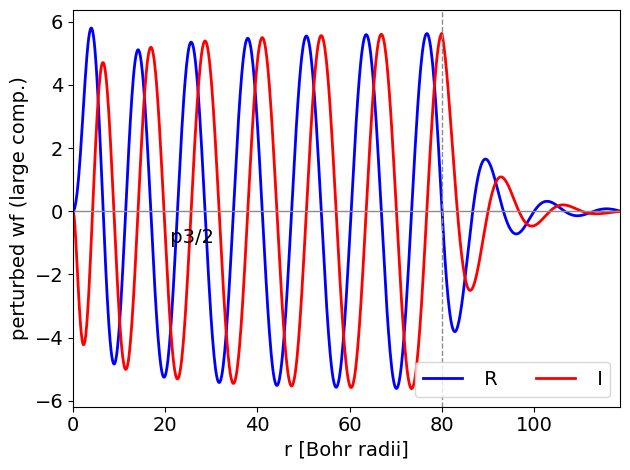

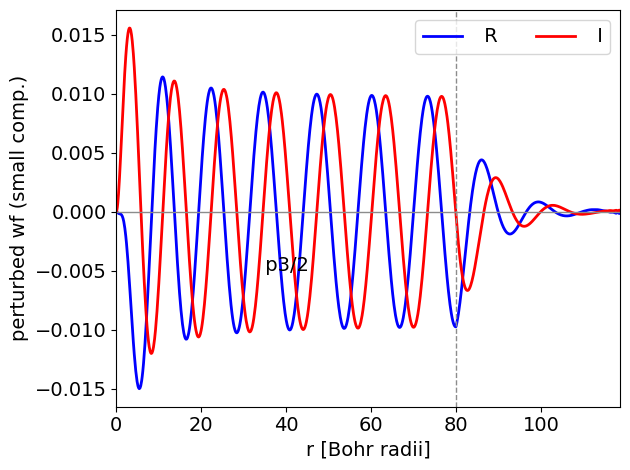

In [14]:
pertf,pertg= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,pwf_1s_p3,rr,ilastf)
pertf_pos,pertg_pos= getfunc_in_r_rel(nknotf,kordf,tf,nknotg,kordg,tg,pwf_1s_p3_pos,rr,ilastf)
ymin=1.1*np.min(np.imag(pertf))
plt.plot(np.real(rr),np.real(pertf), color=mycolor1,linestyle='-',lw=2,label=' R')
# plt.plot(np.real(rr),np.real(pertf_pos), color=mycolor2,linestyle='--',lw=2,label=' R pos')
plt.plot(np.real(rr),np.imag(pertf), color=mycolor2,linestyle='-',lw=2,label=' I')
plt.axvline(x=rotlin, color=mycolor3, linestyle='--',lw=1)
plt.axhline(y=0.0, color=mycolor3, linestyle='-',lw=1)
plt.xlabel('r [Bohr radii]', fontdict=font)
plt.ylabel('perturbed wf (large comp.)', fontdict=font) 
plt.xticks(fontsize = myticksize)
plt.yticks(fontsize = myticksize)
plt.xlim(0,np.real(t[t.size-1]))
textinfig=' p3/2'
plt.text(printmax*0.5, -1,textinfig, fontdict=font)
plt.legend(loc='best',prop={'size':mylegendsize},ncol=4)     
plt.tight_layout()
plt.show()
#############################
plt.plot(np.real(rr), np.real(pertg), color=mycolor1,linestyle='-',lw=2,label=' R')
# plt.plot(np.real(rr), np.real(pertg_pos), color=mycolor2,linestyle='--',lw=2,label=' R pos')
plt.plot(np.real(rr), np.imag(pertg), color=mycolor2,linestyle='-',lw=2,label=' I')
plt.axvline(x=rotlin, color=mycolor3, linestyle='--',lw=1)
plt.axhline(y=0.0, color=mycolor3, linestyle='-',lw=1)
plt.xlabel('r [Bohr radii]', fontdict=font)
plt.ylabel('perturbed wf (small comp.)', fontdict=font) 
plt.xticks(fontsize = myticksize)
plt.yticks(fontsize = myticksize)
plt.xlim(0,np.real(t[t.size-1]))
textinfig=' p3/2'
plt.text(printmax*0.85, -0.005,textinfig, fontdict=font)
plt.legend(loc='best',prop={'size':mylegendsize},ncol=4)     
plt.tight_layout()
plt.tight_layout()
plt.show()
#############################


In [15]:
print(nknotf-kordf-2,nknotg-kordg-2)
f=pwf_1s_p1_pos[0:nknotf-kordf-2]
print(f.size)
print(f[0],pwf_1s_p1_pos[0])
print(f[f.size-1],pwf_1s_p1_pos[nknotf-kordf-3])
g=pwf_1s_p1_pos[f.size:pwf_1s_p1_pos.size]
print(g.size)
print(g[0],pwf_1s_p1_pos[f.size])


127 128
127
(6.851528084263705e-05-6.870947640517712e-06j) (6.851528084263705e-05-6.870947640517712e-06j)
(0.021494235160935644-0.009625185840032937j) (0.021494235160935644-0.009625185840032937j)
128
(0.00036363251891894933-0.001387343373215389j) (0.00036363251891894933-0.001387343373215389j)


In [16]:
rr_f,weights_f,ig_f = getgaussiangrid(tf,nknotf,kordf,multlin)
rr_g,weights_g,ig_g = getgaussiangrid(tg,nknotg,kordg,multlin)

this is the gaussian grid, with 8  points between each  knot point
this is the gaussian grid, with 9  points between each  knot point


In [17]:
#This is the integration part
print('initial state',eigs1[eigas1[istart]])
l1=1.0
l2=l1+1.0
kop=1
eps1=eigs1[eigas1[istart]] +omega
eps2=eigs1[eigas1[istart]] +omega+omega2
# This is the  1s-p1/2 to d 
print('l1=',l1,'e1=',np.round(eps1,4),'l2=',l2,\
    'e2=',np.round(eps2,4),' omg1=',omega*eV,'omg2=',omega2*eV)
#Integrate for f, and g separately
f=pwf_1s_p1_pos[0:nknotf-kordf-2]
g=pwf_1s_p1_pos[f.size:pwf_1s_p1_pos.size]
i=50
while(np.imag(tf[i])<0.000001):
    #print(" checking amplitude and phase in",np.real(tf[i]))
#   from the perturbed wf get amplitude and phase
    amp,ph=getamp_and_phase(nknotf,kordf,tf,f,eps1,l1,tf[i])
#    anaint=analytint(eps1,eps2,tf[i],l1,l2,amp,ph,1)    
    numint=numericalint(f,rr_f,weights_f,tf,nknotf,kordf,l2,eps2,tf[i],1,ig) 
    anaint=analytint(eps1,eps2,tf[i],l1,l2,amp,ph,1)
    print('f: in',np.real(t[i]),'A=',np.round(amp,2),' phase=',np.round(ph,3), \
        ' M=',np.round(numint,1), '+', \
         np.round(anaint,1),'=',np.round(anaint+numint,2))
    i=i+10
i=50
while(np.imag(tf[i])<0.000001):
    #print(" checking amplitude and phase in",np.real(tf[i]))
    amp,ph=getamp_and_phase(nknotg,kordg,tg,g,eps1,l1,tg[i])
#    anaint=analytint(eps1,eps2,tf[i],l1,l2,amp,ph,1)    
    numint=numericalint(g,rr_g,weights_g,tg,nknotg,kordg,l2,eps2,tg[i],1,ig) 
    anaint=analytint(eps1,eps2,tg[i],l1,l2,amp,ph,1)
    print('g: in',np.real(t[i]),'A=',np.round(amp,2),' phase=',np.round(ph,3), \
        ' M=',np.round(numint,1), '+', \
         np.round(anaint,1),'=',np.round(anaint+numint,2))
    i=i+10

initial state (-0.5000066563721353+1.1152578394058438e-13j)
l1= 1.0 e1= (0.1+0j) l2= 2.0 e2= (0.157+0j)  omg1= 16.3268304 omg2= 1.55
f: in 41.0 A= 5.8  phase= 0.0  M= (-486.8-1578.3j) + (230.5+1258.7j) = (-256.25-319.57j)
f: in 51.0 A= 5.8  phase= 0.0  M= (-1717.2-845j) + (1460.9+525.4j) = (-256.23-319.56j)
f: in 61.0 A= 5.8  phase= 0.0  M= (-1566.4+829.1j) + (1310.2-1148.5j) = (-256.22-319.41j)
f: in 71.0 A= 5.8  phase= 0.0  M= (71.3+1503.7j) + (-327.6-1823.3j) = (-256.33-319.51j)
g: in 41.0 A= 0.01  phase= 1.518  M= (2.9-1j) + (-2.1+0.5j) = (0.81-0.5j)
g: in 51.0 A= 0.01  phase= 1.529  M= (1.7-2.9j) + (-0.9+2.3j) = (0.83-0.55j)
g: in 61.0 A= 0.01  phase= 1.535  M= (-0.8-2.8j) + (1.6+2.2j) = (0.82-0.58j)
g: in 71.0 A= 0.01  phase= -4.743  M= (-2.3-0.6j) + (3.1+0j) = (0.78-0.58j)


In [22]:
M_f = -256.25 - 1j * 319.57
M_g = 0.81 - 1j * 0.5

fac = np.sqrt(np.real(eps2) / (np.real(eps2) + 137 ** 2))

print(M_g / M_f)

(-0.00028474742982538683+0.002306328726436288j)


In [23]:
M_f = -256.23 - 1j * 319.56
M_g = 0.83 - 1j * 0.55

fac = np.sqrt(np.real(eps2) / (np.real(eps2) + 137 ** 2))

print(M_g / M_f)

(-0.00022001770595094847+0.0024209064438734146j)


In [24]:
M_f = -256.22 - 1j * 319.41
M_g = 0.82 - 1j * 0.58

fac = np.sqrt(np.real(eps2) / (np.real(eps2) + 137 ** 2))

print(M_g / M_f)

(-0.00014816238542812274+0.002448382435132295j)


In [27]:
xi = np.sqrt(np.real(eps2) / (np.real(eps2) + 2 * 137 ** 2))
xi

np.float64(0.002044799945110753)